In [1]:
import numpy as np
from skimage.transform import resize 
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
# Define output path using pathlib
output_dir = Path('/gws/nopw/j04/wiser_ewsa/mrakotomanga/EPS/Data/Senegal/64x64/full/timesteps')

lead_time = 3
data_set = 'train'

file_t = f'{data_set}-senegal-output-at-lt{lead_time}.npy'
#file_t = f'{data_set}-senegal-output-t0-for-lt{lead_time}.npy'

file_path = output_dir / file_t

file_path_no_ext = file_path.with_suffix('')

# Load the data safely
if file_path.exists():
    data = np.load(file_path)
else:
    raise FileNotFoundError(f"File not found: {file_path}")

In [3]:
resized_data = np.array([
    resize(frame, (32, 32), order=1, preserve_range=True, anti_aliasing=False)
    for frame in data
])

# Ensure binary values after resizing (0 or 1)
resized_data = (resized_data > 0).astype(np.uint8)

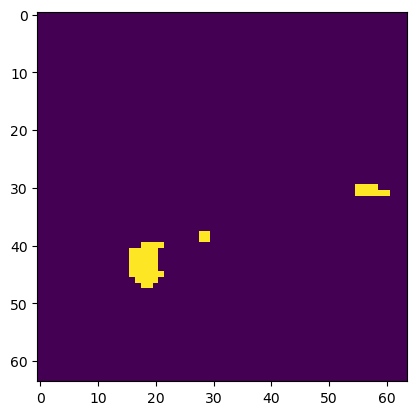

In [4]:
plt.imshow(data[3000])

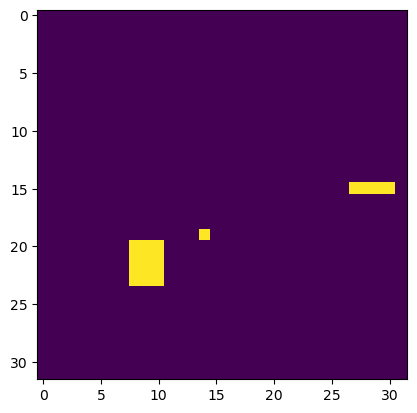

In [5]:
plt.imshow(resized_data[3000])

In [6]:
output_path = file_path_no_ext.with_name(file_path_no_ext.name + '-resized.npy')
np.save(output_path, resized_data)